In [1]:
# import ccxt

# exchange = ccxt.binance()
# histo_btc = exchange.fetch_ohlcv('SOL/USDT', timeframe='1d', limit=1000)

import yfinance as yf
histo_gold = yf.download('GC=F', period='40y', interval='1d')

C:\Users\X515\AppData\Local\Temp\ipykernel_33944\628363181.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  histo_gold = yf.download('GC=F', period='40y', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [2]:
histo_gold = histo_gold.copy()

# Flatten MultiIndex columns like ('close', 'GC=F') -> 'close'
if getattr(histo_gold.columns, "nlevels", 1) > 1:
    histo_gold.columns = histo_gold.columns.get_level_values(0).str.lower()

# Turn index into a regular column named Date
histo_gold = histo_gold.rename_axis("Date").reset_index()

histo_gold.head()
histo_btc = histo_gold.values

# TP2


In [3]:
import pandas as pd

dataset = pd.DataFrame(histo_btc, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'], unit='ms')
print(dataset.columns)
dataset

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


,timestamp,open,high,low,close,volume
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0
1,2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2,2000-09-01,277.0,277.0,277.0,277.0,0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
6416,2026-03-27,4492.0,4492.0,4492.0,4492.0,74348
6417,2026-03-30,4526.0,4579.100098,4413.399902,4482.799805,10816
6418,2026-03-31,4647.600098,4684.100098,4508.600098,4510.0,4264
6419,2026-04-01,4783.200195,4789.100098,4668.0,4668.399902,1637


## Question 1

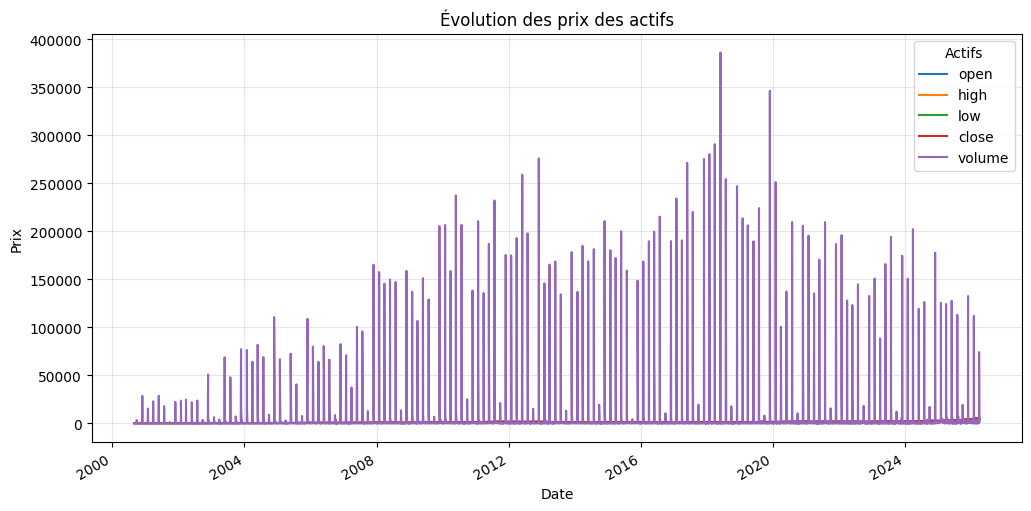

In [4]:
import matplotlib.pyplot as plt

dataset.plot(
    x=dataset.columns[0], 
    y=list(dataset.columns[1:6]),
    kind='line',
    figsize=(12, 6)
)

plt.title("Évolution des prix des actifs")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend(title="Actifs")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
for col in dataset.columns[1:6]:
    print(f"Statistiques pour {col}:")
    print("type : ", dataset[col].dtype)
    print("valeurs uniques : ", dataset[col].nunique())
    print("valeurs manquantes : ", dataset[col].isna().sum())
    print(dataset[col].describe(), end="\n\n")

Statistiques pour open:
type :  object
valeurs uniques :  5166
valeurs manquantes :  0
count     6421.000000
unique    5166.000000
top       1273.699951
freq         6.000000
Name: open, dtype: float64

Statistiques pour high:
type :  object
valeurs uniques :  5097
valeurs manquantes :  0
count     6421.0
unique    5097.0
top        272.5
freq         5.0
Name: high, dtype: float64

Statistiques pour low:
type :  object
valeurs uniques :  5061
valeurs manquantes :  0
count     6421.0
unique    5061.0
top        422.0
freq         8.0
Name: low, dtype: float64

Statistiques pour close:
type :  object
valeurs uniques :  5112
valeurs manquantes :  0
count     6421.0
unique    5112.0
top        272.5
freq         6.0
Name: close, dtype: float64

Statistiques pour volume:
type :  object
valeurs uniques :  1645
valeurs manquantes :  0
count     6421
unique    1645
top          0
freq       418
Name: volume, dtype: int64



# Question 2

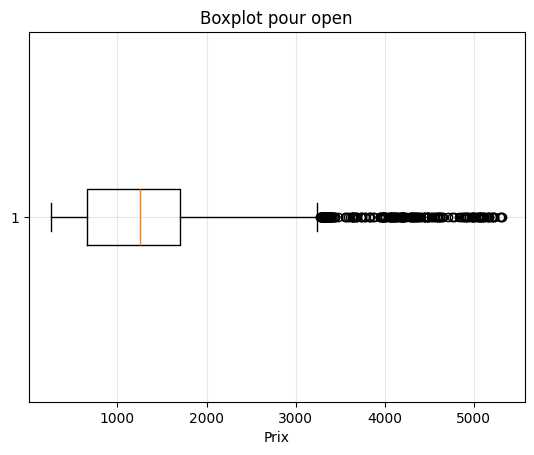

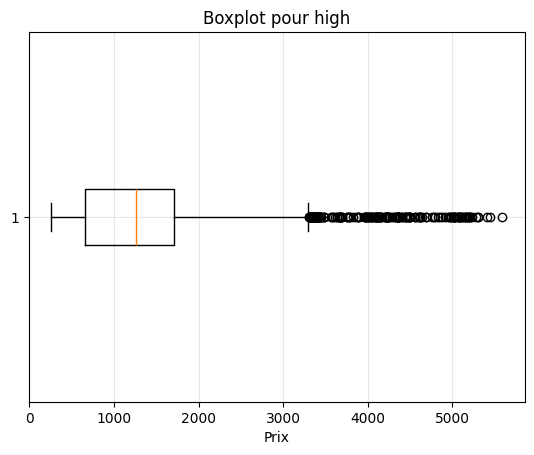

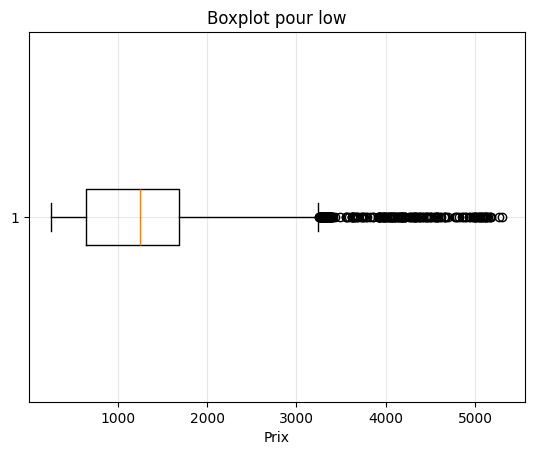

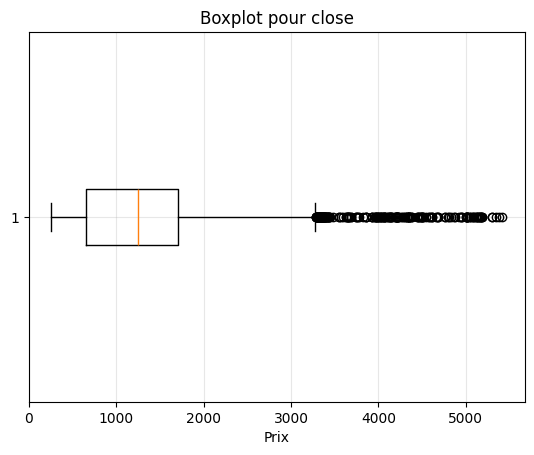

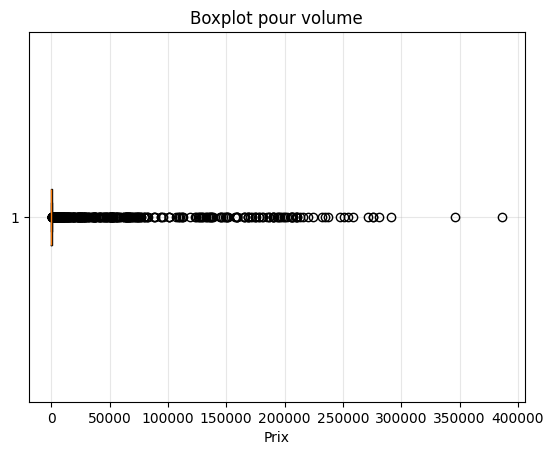

In [7]:
for col in dataset.columns[1:6]:
    plt.boxplot(dataset[col], vert=False)
    plt.title(f"Boxplot pour {col}")
    plt.xlabel("Prix")
    plt.grid(True, alpha=0.3)
    plt.show()

# Question 3

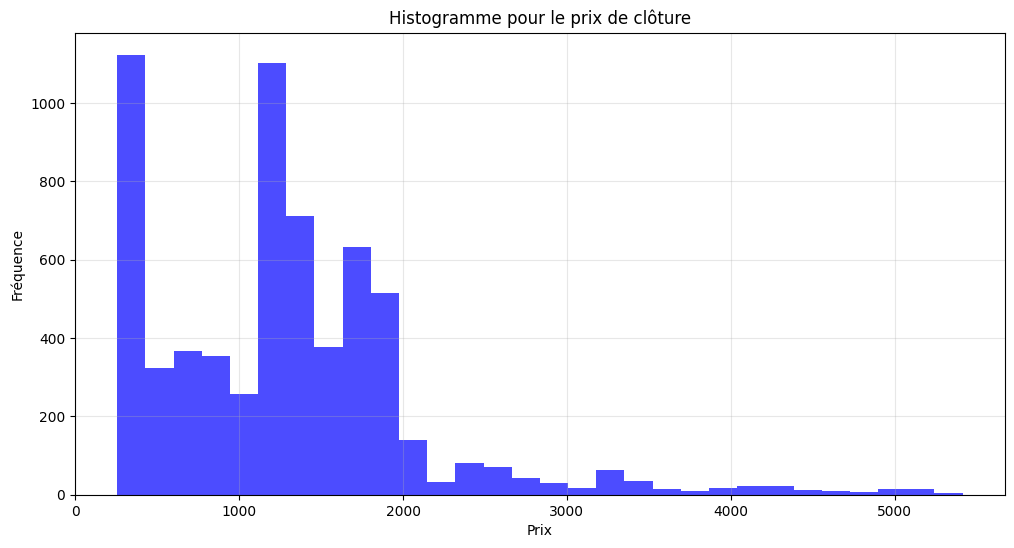

In [8]:
plt.figure(figsize=(12, 6))
plt.hist(dataset['close'], bins=30, alpha=0.7, color='blue')
plt.title("Histogramme pour le prix de clôture")
plt.xlabel("Prix")
plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.show()

# Question 4

<Figure size 1200x600 with 0 Axes>

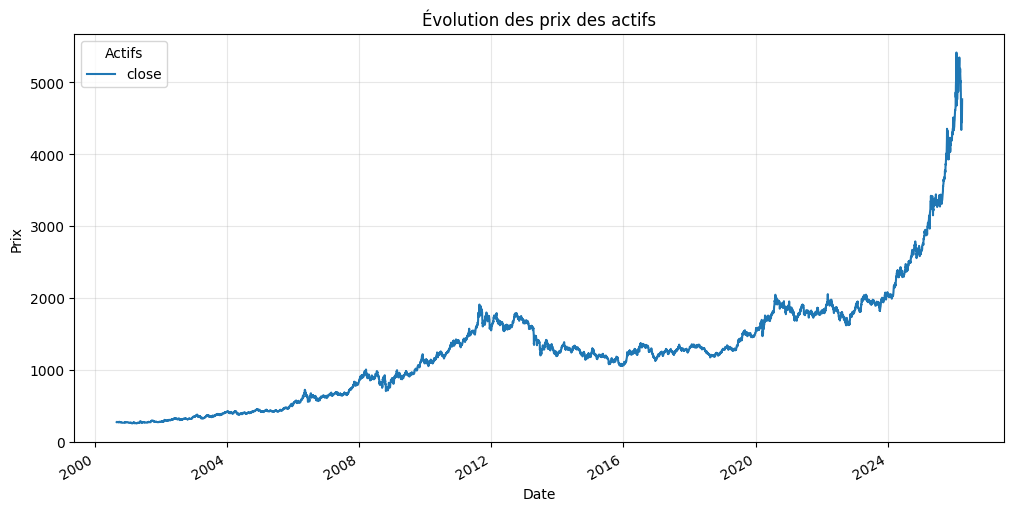

In [9]:
plt.figure(figsize=(12, 6))
dataset.plot(
    x='timestamp', 
    y='close',
    kind='line',
    figsize=(12, 6)
)
plt.title("Évolution des prix des actifs")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend(title="Actifs")
plt.grid(True, alpha=0.3)
plt.show()

# Question 5

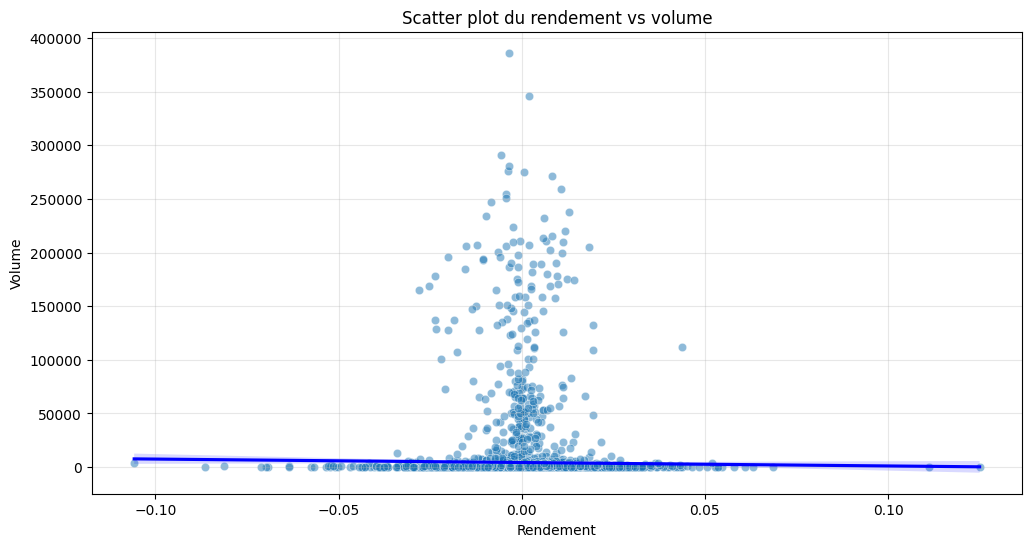

Correlation entre volume et return :  -0.015119043152547014


In [25]:
import seaborn as sns

dataset['close'] = pd.to_numeric(dataset['close'], errors='coerce')
dataset['volume'] = pd.to_numeric(dataset['volume'], errors='coerce')

dataset['return'] = dataset['close'].pct_change()
dataset['absolute_return'] = dataset['close'].diff()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset, x='return', y='volume', alpha=0.5)
sns.regplot(data=dataset, x='return', y='volume', scatter=False, color='blue')
plt.title("Scatter plot du rendement vs volume")
plt.xlabel("Rendement")
plt.ylabel("Volume")
plt.grid(True, alpha=0.3)
plt.show()

print("Correlation entre volume et return : ", dataset['volume'].corr(dataset['return']))

# Question 6

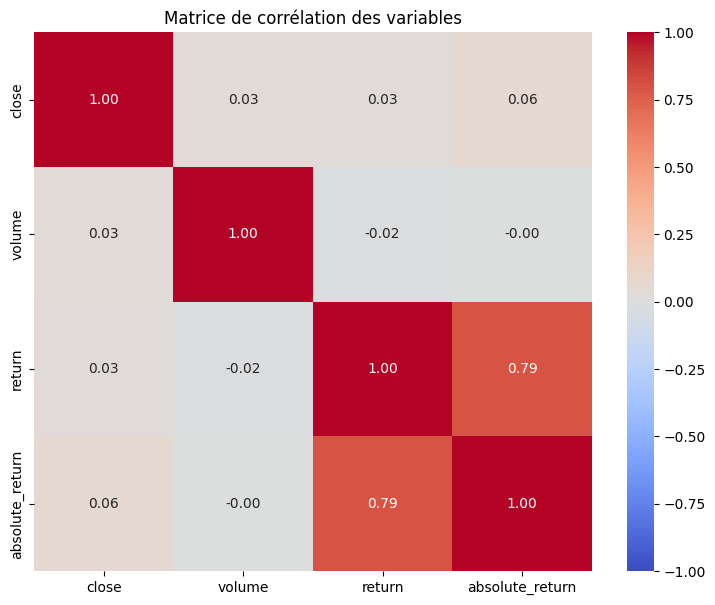

In [38]:
import numpy as np

vars_analyse = ['close', 'volume', 'return', 'absolute_return']

corr = dataset[vars_analyse].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables")
plt.show()